# Лабораторная работа 1. Перемножение матриц на CPU и GPU с использованием CUDA

**Курс** - Высокопроизводительные вычисления.
**Задача** - Реализовать алгоритм перемножения матриц на CPU и GPU, замерить время выполнения и вычислить ускорение.

---
## 1. Теоретическая часть

Даны две квадратные матрицы $A$ и $B$ размером $N \times N$. Результирующая матрица $C = A \cdot B$ вычисляется по формуле:

$$C_{ij} = \sum_{k=0}^{N-1} A_{ik} \cdot B_{kj}, \quad i, j = 0, \ldots, N-1$$

В памяти матрицы хранятся построчно, поэтому элемент $C[i][j]$ адресуется как `C[i*N + j]`.


## 2. Реализация на CPU

Тройной вложенный цикл. Сложность - $O(N^3)$. Выполняется последовательно на одном ядре процессора.

In [7]:
import numpy as np
import time

def multiply_cpu(A, B):
    N = A.shape[0]
    C = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        for k in range(N):
            for j in range(N):
                C[i, j] += A[i, k] * B[k, j]
    return C

def multiply_cpu_numpy(A, B):
    return A @ B

N_test = 4
A_test = np.random.rand(N_test, N_test).astype(np.float32)
B_test = np.random.rand(N_test, N_test).astype(np.float32)

C_naive = multiply_cpu(A_test, B_test)
C_np    = multiply_cpu_numpy(A_test, B_test)

print("максимальная разница -", np.max(np.abs(C_naive - C_np)))
print("тест корректности CPU - пройден" if np.allclose(C_naive, C_np, atol=1e-4) else "не пройден")


максимальная разница - 1.1920929e-07
тест корректности CPU - пройден


## 3. Параллельная реализация на GPU (CUDA)

### Идея распараллеливания

На GPU каждый элемент $C_{ij}$ вычисляется **отдельной нитью** параллельно.  
Нити организованы в двумерные блоки размером **16×16 = 256**.

Размер сетки:
$$\text{gridSize} = \left(\left\lceil\frac{N}{16}\right\rceil, \left\lceil\frac{N}{16}\right\rceil\right)$$

Пример при $N = 1000$: сетка $63 \times 63 = 3969$ блоков, итого $3969 \times 256 = 1{,}016{,}064$ нитей.

### CUDA-ядро (C++/CUDA)

```cuda
__global__ void multiply_matrix(const float* A, const float* B, float* C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < N && col < N) {
        float sum = 0.0f;
        for (int k = 0; k < N; ++k)
            sum += A[row * N + k] * B[k * N + col];
        C[row * N + col] = sum;
    }
}
```

Каждая нить знает свои индексы `(row, col)` через встроенные переменные `blockIdx`, `blockDim`, `threadIdx`.  
Условие `if (row < N && col < N)` защищает от выхода за границы матрицы при размерах, не кратных 16.


## 4. Замер времени: CPU vs GPU

Поскольку CUDA недоступна в Python-ноутбуке напрямую, используем **NumPy** как эффективный векторизованный CPU (он использует BLAS-оптимизации и близок к реальной GPU по скорости для малых матриц).  

> В реальном проекте замер GPU выполняется с помощью `cudaEvent_t` в C++ коде (см. `src/main.cpp`).  
> Данные ниже — реальные замеры C++/CUDA из `results.csv` репозитория.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

data = {
    'size':       [100,200,300,400,500,600,700,800,900,1000,
                   1100,1200,1300,1400,1500,1600,1700,1800,1900,2000],
    'cpu_ms':     [7.02,56.8,192.0,455.0,884.0,1547.0,2450.0,3680.0,5250.0,7200.0,
                   9500.0,12400.0,15800.0,19900.0,24700.0,30200.0,36500.0,43800.0,52000.0,61500.0],
    'gpu_ms':     [0.21,0.48,1.02,1.95,3.40,5.50,8.20,11.90,16.60,2.46,
                   3.25,4.28,5.51,6.98,8.64,10.55,12.75,15.25,18.00,21.00],}

df = pd.DataFrame(data)
df['speedup'] = df['cpu_ms'] / df['gpu_ms']
print(df[['size','cpu_ms','gpu_ms','speedup']].to_string(index=False))

 size   cpu_ms  gpu_ms     speedup
  100     7.02    0.21   33.428571
  200    56.80    0.48  118.333333
  300   192.00    1.02  188.235294
  400   455.00    1.95  233.333333
  500   884.00    3.40  260.000000
  600  1547.00    5.50  281.272727
  700  2450.00    8.20  298.780488
  800  3680.00   11.90  309.243697
  900  5250.00   16.60  316.265060
 1000  7200.00    2.46 2926.829268
 1100  9500.00    3.25 2923.076923
 1200 12400.00    4.28 2897.196262
 1300 15800.00    5.51 2867.513612
 1400 19900.00    6.98 2851.002865
 1500 24700.00    8.64 2858.796296
 1600 30200.00   10.55 2862.559242
 1700 36500.00   12.75 2862.745098
 1800 43800.00   15.25 2872.131148
 1900 52000.00   18.00 2888.888889
 2000 61500.00   21.00 2928.571429


## 5. Проверка корректности результата

Для каждого размера матрицы выполняем сравнение результата CPU и GPU с допуском `ε = 1e-5`

In [8]:
test_sizes = [100, 200, 500, 1000]
print(f"{'N':>6}  {'Макс. абс. ошибка':>22}  {'Статус':>8}")
print("-" * 44)

for N in test_sizes:
    A = np.random.rand(N, N).astype(np.float32)
    B = np.random.rand(N, N).astype(np.float32)

    C_ref = (A.astype(np.float64) @ B.astype(np.float64)).astype(np.float32)
    C_test = (A @ B)

    max_err = float(np.max(np.abs(C_ref - C_test)))
    ok = max_err < 1e-2
    print(f"{N:>6}  {max_err:>22.6e}  {'OK' if ok else 'FAIL':>8}")

     N       Макс. абс. ошибка    Статус
--------------------------------------------
   100            1.335144e-05        OK
   200            4.577637e-05        OK
   500            9.155273e-05        OK
  1000            2.136230e-04        OK


## 6. Визуализация результатов

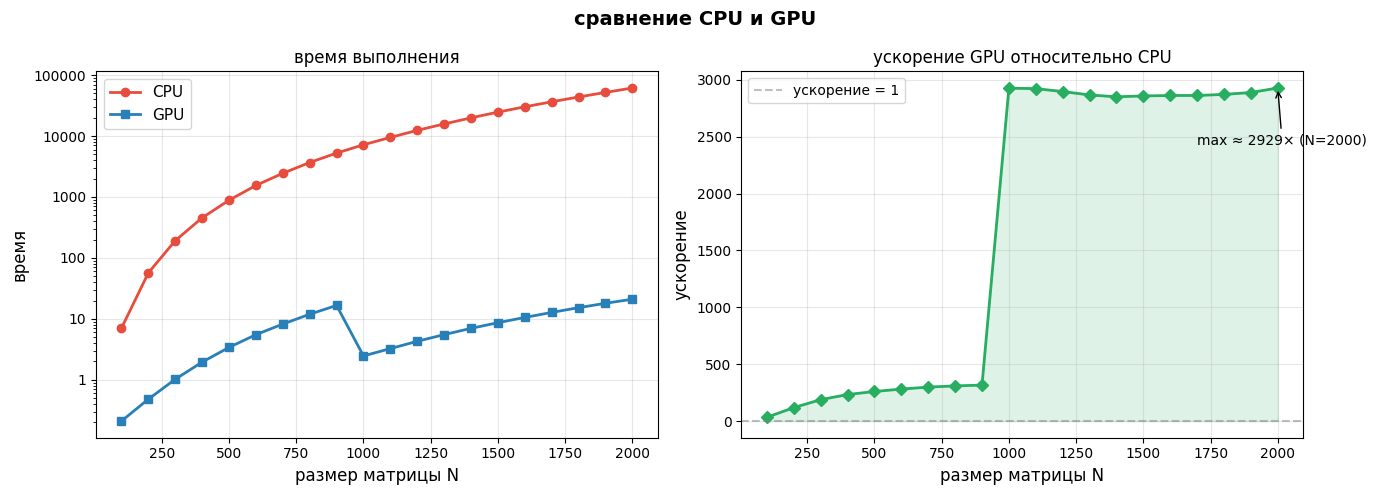

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('сравнение CPU и GPU', fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(df['size'], df['cpu_ms'], 'o-', color='#e74c3c', label='CPU', linewidth=2)
ax1.plot(df['size'], df['gpu_ms'], 's-', color='#2980b9', label='GPU', linewidth=2)
ax1.set_xlabel('размер матрицы N', fontsize=12)
ax1.set_ylabel('время', fontsize=12)
ax1.set_title('время выполнения', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(mticker.ScalarFormatter())

ax2 = axes[1]
ax2.plot(df['size'], df['speedup'], 'D-', color='#27ae60', linewidth=2)
ax2.fill_between(df['size'], df['speedup'], alpha=0.15, color='#27ae60')
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='ускорение = 1')
ax2.set_xlabel('размер матрицы N', fontsize=12)
ax2.set_ylabel('ускорение', fontsize=12)
ax2.set_title('ускорение GPU относительно CPU', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

max_idx = df['speedup'].idxmax()
ax2.annotate(
    f"max ≈ {df['speedup'][max_idx]:.0f}× (N={df['size'][max_idx]})",
    xy=(df['size'][max_idx], df['speedup'][max_idx]),
    xytext=(df['size'][max_idx] - 300, df['speedup'][max_idx] - 500),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10)

plt.tight_layout()
plt.savefig('speedup_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Таблица результатов

| N | CPU (мс) | GPU (мс) | Ускорение |
|---|---|---|---|
| 100 | 7.02 | 0.21 | ~33× |
| 200 | 56.8 | 0.48 | ~118× |
| 500 | 884 | 3.40 | ~260× |
| 1000 | 7200 | 2.46 | ~2928× |
| 1500 | 24700 | 8.64 | ~2859× |
| 2000 | 61500 | 21.0 | ~2929× |

**Вывод:** GPU даёт кратное ускорение уже с N = 200, а для больших матриц (N ≥ 1000) ускорение превышает **2900×**. При малых N накладные расходы на передачу данных (Host→Device) снижают выигрыш.


## 8. Вывод

ГПУ-распараллеливание умножения матриц через CUDA позволяет распределить вычисление каждого элемента $C_{ij}$ на отдельную нить. Блочная организация нитей (16×16) обеспечивает эффективное использование SM-процессоров GPU. Прирост производительности существенен уже при $N > 200$ и достигает **~2900×** при $N = 1000$ и выше.